<a href="https://colab.research.google.com/github/Saswat545/Autism-ML-Project/blob/main/Autism_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import pandas as pd
import numpy as np

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [70]:
df = pd.read_csv('train.csv')

In [71]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [72]:
print("Shape:", df.shape)

Shape: (800, 22)


In [73]:
print("Columns:", df.columns)

Columns: Index(['ID', 'A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score',
       'A6_Score', 'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age',
       'gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'result', 'age_desc', 'relation', 'Class/ASD'],
      dtype='object')


In [74]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [75]:
df.isnull().sum()

,0
ID,0
A1_Score,0
A2_Score,0
A3_Score,0
A4_Score,0
A5_Score,0
A6_Score,0
A7_Score,0
A8_Score,0
A9_Score,0


In [76]:
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

In [77]:
df.dropna(inplace=True)

In [78]:
le = LabelEncoder()

In [79]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [80]:
target_column = 'Class/ASD'

In [81]:
X = df.drop(target_column, axis=1)
y = df[target_column]

In [82]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (800, 20)
Target shape: (800,)


In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (640, 20)
Testing data: (160, 20)


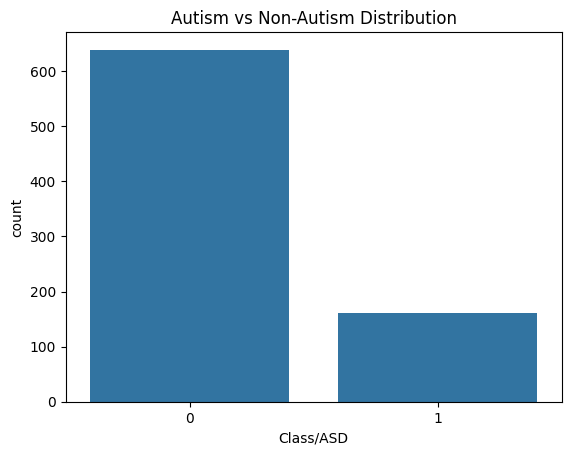

In [84]:
sns.countplot(x=y)
plt.title("Autism vs Non-Autism Distribution")
plt.show()

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [86]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [87]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [88]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [89]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [90]:
y_pred_lr = lr.predict(X_test)

In [91]:
y_pred_dt = dt.predict(X_test)

In [92]:
y_pred_rf = rf.predict(X_test)

In [93]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n===== {model_name} =====")

In [94]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n===== {model_name} =====")

    # Accuracy
    print("Accuracy:", accuracy_score(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    # Plot Confusion Matrix
    import seaborn as sns
    import matplotlib.pyplot as plt

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Classification Report
    print("Classification Report:\n", classification_report(y_test, y_pred))


===== Logistic Regression =====
Accuracy: 0.8625
Confusion Matrix:
 [[115   9]
 [ 13  23]]


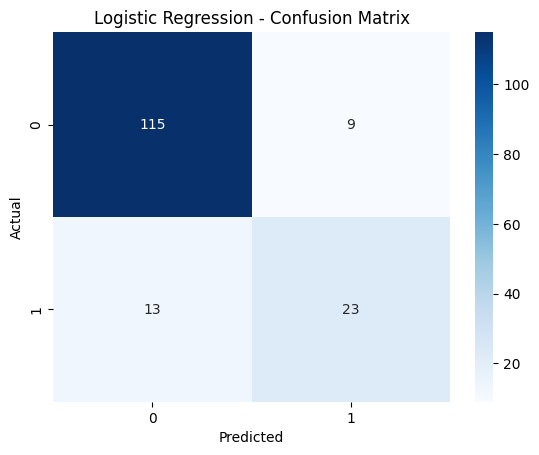

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.93      0.91       124
           1       0.72      0.64      0.68        36

    accuracy                           0.86       160
   macro avg       0.81      0.78      0.79       160
weighted avg       0.86      0.86      0.86       160


===== Decision Tree =====
Accuracy: 0.83125
Confusion Matrix:
 [[113  11]
 [ 16  20]]


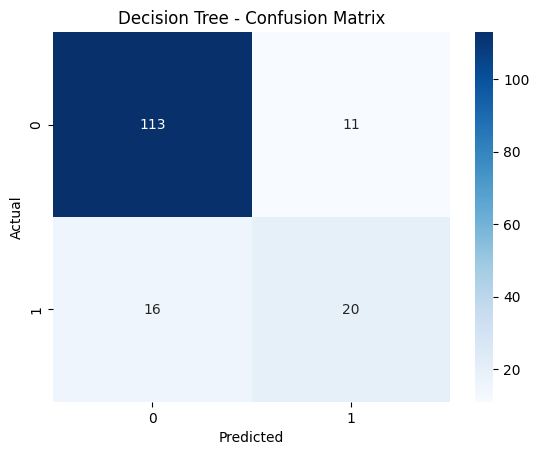

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.91      0.89       124
           1       0.65      0.56      0.60        36

    accuracy                           0.83       160
   macro avg       0.76      0.73      0.75       160
weighted avg       0.82      0.83      0.83       160


===== Random Forest =====
Accuracy: 0.85
Confusion Matrix:
 [[114  10]
 [ 14  22]]


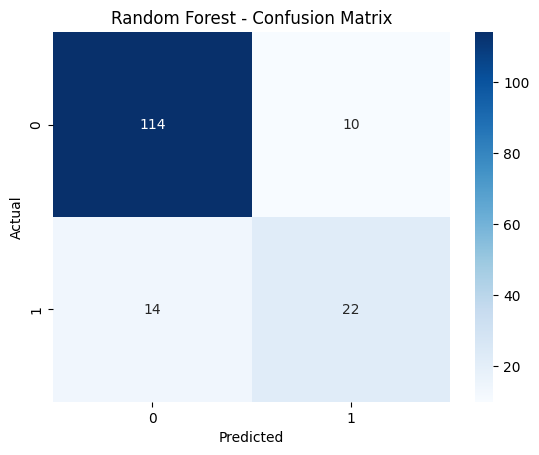

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.92      0.90       124
           1       0.69      0.61      0.65        36

    accuracy                           0.85       160
   macro avg       0.79      0.77      0.78       160
weighted avg       0.84      0.85      0.85       160



In [95]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")
evaluate_model(y_test, y_pred_dt, "Decision Tree")
evaluate_model(y_test, y_pred_rf, "Random Forest")

In [96]:
results = []

def get_metrics(y_test, y_pred, model_name):
    from sklearn.metrics import precision_score, recall_score, f1_score

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

# Collect metrics
get_metrics(y_test, y_pred_lr, "Logistic Regression")
get_metrics(y_test, y_pred_dt, "Decision Tree")
get_metrics(y_test, y_pred_rf, "Random Forest")

# Create DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.86250,0.718750,0.638889,0.676471
1,Decision Tree,0.83125,0.645161,0.555556,0.597015
2,Random Forest,0.85000,0.687500,0.611111,0.647059


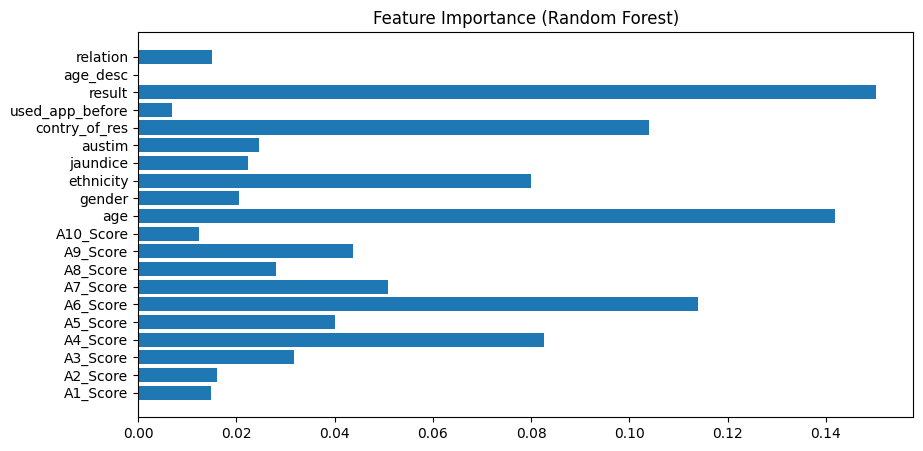

In [97]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

# Plot
plt.figure(figsize=(10,5))
plt.barh(features, importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

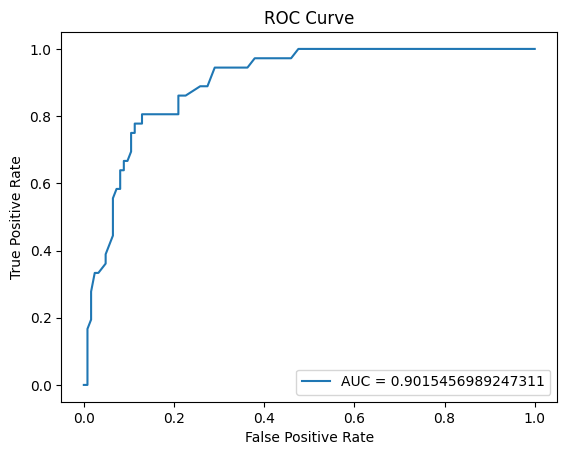

In [98]:
from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = " + str(roc_auc))
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [99]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(rf, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average score:", scores.mean())

Cross-validation scores: [0.80625 0.85625 0.875   0.85625 0.86875]
Average score: 0.8525
